Vamos utilizar a decomposição de Cholesky para gerar dados sintéticos correlacionados. Toda matriz de covariancia, por ser simétrica e positivo-definida (auto-valores positivos não nulos) admite decomposição de Cholesky. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 12
x = np.linspace(0, 10, n)


[PASSO 1] Dados NAO correlacionados z (12 pontos):
[ 0.4967 -0.1383  0.6477  1.523  -0.2342 -0.2341  1.5792  0.7674 -0.4695
  0.5426 -0.4634 -0.4657]

[PASSO 2] Matriz de CORRELACAO C (diagonal = 1):
[[1.     0.6703 0.4493 0.3012 0.2019 0.1353 0.0907 0.0608 0.0408 0.0273
  0.0183 0.0123]
 [0.6703 1.     0.6703 0.4493 0.3012 0.2019 0.1353 0.0907 0.0608 0.0408
  0.0273 0.0183]
 [0.4493 0.6703 1.     0.6703 0.4493 0.3012 0.2019 0.1353 0.0907 0.0608
  0.0408 0.0273]
 [0.3012 0.4493 0.6703 1.     0.6703 0.4493 0.3012 0.2019 0.1353 0.0907
  0.0608 0.0408]
 [0.2019 0.3012 0.4493 0.6703 1.     0.6703 0.4493 0.3012 0.2019 0.1353
  0.0907 0.0608]
 [0.1353 0.2019 0.3012 0.4493 0.6703 1.     0.6703 0.4493 0.3012 0.2019
  0.1353 0.0907]
 [0.0907 0.1353 0.2019 0.3012 0.4493 0.6703 1.     0.6703 0.4493 0.3012
  0.2019 0.1353]
 [0.0608 0.0907 0.1353 0.2019 0.3012 0.4493 0.6703 1.     0.6703 0.4493
  0.3012 0.2019]
 [0.0408 0.0608 0.0907 0.1353 0.2019 0.3012 0.4493 0.6703 1.     0.6703
  0.4493 0.3012

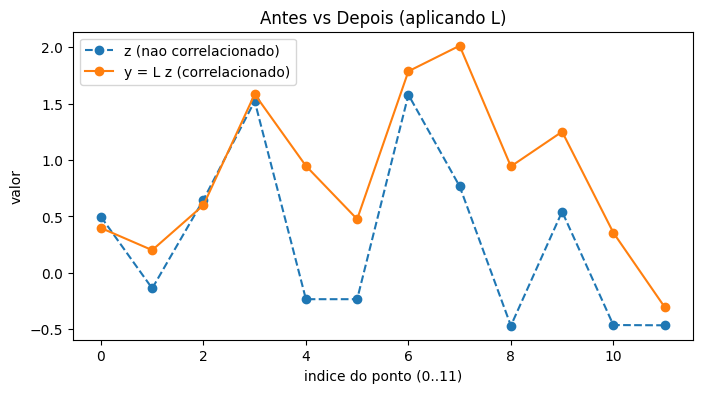


[PASSO 7] Covariancia empirica (M=5000) deve aproximar Sigma:
[[0.6496 0.4725 0.3461 0.2424 0.1621 0.1282 0.0899 0.0369 0.0565 0.0441
  0.0466 0.0186]
 [0.4725 0.7541 0.5593 0.4039 0.2875 0.2117 0.1406 0.0841 0.0812 0.0498
  0.0507 0.0178]
 [0.3461 0.5593 0.9182 0.6535 0.4682 0.34   0.2501 0.1646 0.1224 0.0827
  0.0627 0.0554]
 [0.2424 0.4039 0.6535 1.0473 0.7469 0.542  0.3961 0.2844 0.226  0.1639
  0.1317 0.1029]
 [0.1621 0.2875 0.4682 0.7469 1.1936 0.8527 0.6152 0.4241 0.3336 0.2404
  0.1661 0.1197]
 [0.1282 0.2117 0.34   0.542  0.8527 1.3557 0.9617 0.6908 0.5063 0.3681
  0.2496 0.1537]
 [0.0899 0.1406 0.2501 0.3961 0.6152 0.9617 1.5381 1.0866 0.7596 0.5495
  0.3888 0.2661]
 [0.0369 0.0841 0.1646 0.2844 0.4241 0.6908 1.0866 1.706  1.1942 0.8543
  0.6094 0.4235]
 [0.0565 0.0812 0.1224 0.226  0.3336 0.5063 0.7596 1.1942 1.8767 1.3435
  0.9571 0.6643]
 [0.0441 0.0498 0.0827 0.1639 0.2404 0.3681 0.5495 0.8543 1.3435 2.1165
  1.5226 1.0782]
 [0.0466 0.0507 0.0627 0.1317 0.1661 0.2496 0.3

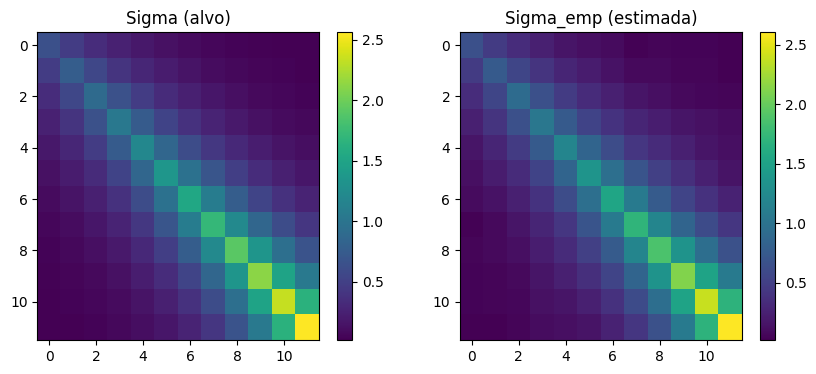

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

# ------------------------------------------------------------
# 1) Gerar "dados não correlacionados" (12 pontos)
# ------------------------------------------------------------
n = 12
z = np.random.randn(n)  # i.i.d. ~ N(0,1)

print("\n[PASSO 1] Dados NAO correlacionados z (12 pontos):")
print(z)

# ------------------------------------------------------------
# 2) Gerar matriz de CORRELACAO C (diagonal = 1)
#    Vamos criar C com um modelo simples e SPD:
#    C_ij = exp(-|i-j|/tau)  (toeplitz; sempre SPD para tau>0)
# ------------------------------------------------------------
tau = 2.5
idx = np.arange(n)
C = np.exp(-np.abs(idx[:, None] - idx[None, :]) / tau)

print("\n[PASSO 2] Matriz de CORRELACAO C (diagonal = 1):")
print(C)
print("\nDiagonal de C (tem que ser 1):")
print(np.diag(C))

# ------------------------------------------------------------
# 3) Construir matriz de COVARIANCIA Sigma a partir de C
#    Sigma_ij = C_ij * sqrt(Sigma_ii) * sqrt(Sigma_jj)
#    Equivalentemente: Sigma = D C D, D = diag(sigmas)
# ------------------------------------------------------------
sigmas = np.linspace(0.8, 1.6, n)   # desvio-padrão de cada ponto (exemplo)
D = np.diag(sigmas)
Sigma = D @ C @ D

print("\n[PASSO 3] Desvios-padrao escolhidos (sigmas):")
print(sigmas)

print("\n[PASSO 3] Matriz de COVARIANCIA Sigma = D C D:")
print(Sigma)

print("\nDiagonal de Sigma (variancias) = sigmas^2:")
print(np.diag(Sigma))
print("\nsigmas^2:")
print(sigmas**2)

# ------------------------------------------------------------
# 4) Decomposicao de Cholesky na covariancia: Sigma = L L^T
# ------------------------------------------------------------
jitter = 1e-12
L = np.linalg.cholesky(Sigma + jitter*np.eye(n))

print("\n[PASSO 4] Matriz L da Cholesky (triangular inferior):")
print(L)

print("\n[PASSO 4] Checagem: ||Sigma - L L^T|| (deve ser ~0):")
print(np.linalg.norm(Sigma - L @ L.T))

# ------------------------------------------------------------
# 5) Gerar dados correlacionados aplicando L nos dados nao correlacionados
# ------------------------------------------------------------
y = L @ z

print("\n[PASSO 5] Dados correlacionados y = L z:")
print(y)

# ------------------------------------------------------------
# 6) Visualizacao (um exemplo: antes vs depois)
# ------------------------------------------------------------
x = np.arange(n)

plt.figure(figsize=(8,4))
plt.plot(x, z, "o--", label="z (nao correlacionado)")
plt.plot(x, y, "o-",  label="y = L z (correlacionado)")
plt.xlabel("indice do ponto (0..11)")
plt.ylabel("valor")
plt.title("Antes vs Depois (aplicando L)")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 7) (Opcional, mas MUITO convincente) Validar Sigma empiricamente
#    Geramos muitas realizacoes e comparamos covariancia amostral com Sigma
# ------------------------------------------------------------
M = 5000
Z = np.random.randn(M, n)
Y = (Z @ L.T)   # equivalente a y = L z (para cada amostra)

Sigma_emp = np.cov(Y, rowvar=False)

print("\n[PASSO 7] Covariancia empirica (M=5000) deve aproximar Sigma:")
print(Sigma_emp)

print("\n[PASSO 7] Erro relativo Frobenius ||Sigma_emp - Sigma|| / ||Sigma|| :")
print(np.linalg.norm(Sigma_emp - Sigma) / np.linalg.norm(Sigma))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(Sigma, aspect="auto")
plt.title("Sigma (alvo)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(Sigma_emp, aspect="auto")
plt.title("Sigma_emp (estimada)")
plt.colorbar()
plt.show()

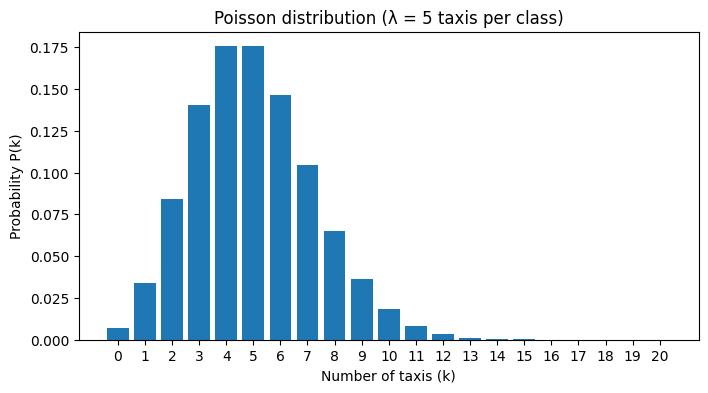

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial, exp

# parâmetro da Poisson (média de táxis)
lam = 5

# valores de k (0 até 20 táxis)
k = np.arange(0, 21)

# distribuição de Poisson
P = np.array([exp(-lam) * lam**ki / factorial(ki) for ki in k])

# plot
plt.figure(figsize=(8,4))
plt.bar(k, P, width=0.8)
plt.xlabel("Number of taxis (k)")
plt.ylabel("Probability P(k)")
plt.title("Poisson distribution (λ = 5 taxis per class)")
plt.xticks(k)
plt.show()

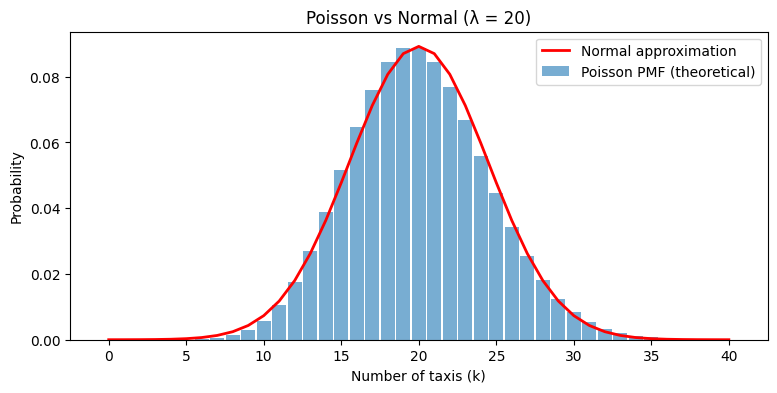

sum(P_poisson) = 0.9999745736817615
min(P_poisson) = 2.061153622438558e-09


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

lam = 20
k = np.arange(0, 41)

P_poisson = poisson.pmf(k, mu=lam)        # estável e correto
P_normal  = norm.pdf(k, loc=lam, scale=np.sqrt(lam))  # aproximação

plt.figure(figsize=(9,4))
plt.bar(k, P_poisson, width=0.9, alpha=0.6, label="Poisson PMF (theoretical)")
plt.plot(k, P_normal, "r-", lw=2, label="Normal approximation")
plt.xlabel("Number of taxis (k)")
plt.ylabel("Probability")
plt.title("Poisson vs Normal (λ = 20)")
plt.legend()
plt.show()

print("sum(P_poisson) =", P_poisson.sum())
print("min(P_poisson) =", P_poisson.min())

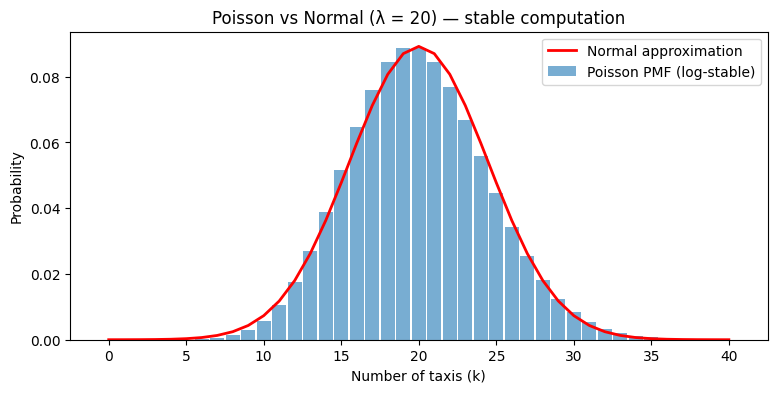

sum(P_poisson) = 0.9999745736817629
min(P_poisson) = 2.061153622438558e-09


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math

lam = 20
k = np.arange(0, 41)

# log PMF: log P(k) = -lam + k*log(lam) - log(k!)
logP = np.array([-lam + ki*math.log(lam) - math.lgamma(ki+1) for ki in k])
P_poisson = np.exp(logP)

# Normal approx
P_normal = (1/np.sqrt(2*np.pi*lam)) * np.exp(-(k-lam)**2/(2*lam))

plt.figure(figsize=(9,4))
plt.bar(k, P_poisson, width=0.9, alpha=0.6, label="Poisson PMF (log-stable)")
plt.plot(k, P_normal, "r-", lw=2, label="Normal approximation")
plt.xlabel("Number of taxis (k)")
plt.ylabel("Probability")
plt.title("Poisson vs Normal (λ = 20) — stable computation")
plt.legend()
plt.show()

print("sum(P_poisson) =", P_poisson.sum())
print("min(P_poisson) =", P_poisson.min())